In [18]:
from pathlib import Path
import sys

# Allow running the notebook from its folder without installing the package.
repo_root = Path.cwd().resolve()
while repo_root.name != "QuPCA" and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Custom implementation 

source: *A Low-Complexity Quantum Principal Component Analysis Algorithm*
https://doi.org/10.1109/TQE.2021.3140152

In [19]:
import warnings

import numpy as np
from qiskit import transpile

try:
    from qiskit_aer import Aer
except ImportError:
    from qiskit import Aer

from QPCA import (
    PeCircuitBuilder,
    QramBuilder,
    StateVectorTomography,
    generate_matrix,
    general_postprocessing,
 )
from QPCA.preprocessingUtilities.preprocessing import check_matrix_dimension

warnings.filterwarnings("ignore")

### Package utilities used here

This tutorial reuses the package implementation end to end instead of duplicating the internal helper functions in notebook cells.

Phase mapping:
- matrix generation and normalization use `generate_matrix` and `check_matrix_dimension`;
- custom preprocessing uses `QramBuilder.generate_qram_circuit(..., optimized_qram=False)`;
- phase estimation uses `PeCircuitBuilder.generate_PE_circuit(...)`;
- signed statevector reconstruction uses `StateVectorTomography.state_vector_tomography(...)`;
- eigenpair extraction uses `general_postprocessing(...)`.

The only local helper kept below is the final projection step used for the side-by-side comparison with a classical PCA-style transform. It is intentionally notebook-local because it rescales by `sqrt(eigenvalues)`, while `QPCA.transform` is an instance method with different semantics.

In [20]:
# Notebook-local comparison helper, not part of the package API.
def project_onto_components(original_matrix, eigenvalues, components):
    """Project onto components with the same scaling convention used by PCA tutorials.


    This helper stays local to the notebook on purpose: it divides by sqrt(eigenvalues),
    while QPCA.transform operates on a fitted model and exposes a different contract.
    """
    components = np.array(components)
    transformed_matrix = np.dot(original_matrix, components.T)
    transformed_matrix /= np.sqrt(eigenvalues)

    return transformed_matrix

## Main

#### Generate synthetic data

In [21]:
# Change this to False to generate a random matrix with chosen eigenvalues
replicate_paper = True
matrix_dimension = 2
eigval_list = np.array([1, 4])

eigenvalues_list = None if replicate_paper else eigval_list.tolist()
raw_matrix = generate_matrix(
    matrix_dimension=matrix_dimension,
    eigenvalues_list=eigenvalues_list,
    replicate_paper=replicate_paper,
    seed=19,
 )
norm_factor = np.trace(raw_matrix)
normalized_matrix = raw_matrix / norm_factor
example_matrix = check_matrix_dimension(normalized_matrix.copy())
original_matrix = raw_matrix

print(f"Working matrix shape for preprocessing and PE: {example_matrix.shape}")

Matrix:
 [[1.5 0.5]
 [0.5 1.5]]

eigenvalue: 1.0 - eigenvector: [-0.707  0.707]
eigenvalue: 2.0 - eigenvector: [0.707 0.707]
Working matrix shape for preprocessing and PE: (2, 2)


as an example, we take the 2x2 matrix used in the original paper
$$
A_0=\left[\begin{array}{ll}
1.5 & 0.5 \\
0.5 & 1.5
\end{array}\right]
$$

whose quantum state is given by
$$\left|\psi_{A_0}\right\rangle=\frac{3}{\sqrt{20}}|00\rangle+\frac{1}{\sqrt{20}}|01\rangle+\frac{1}{\sqrt{20}}|10\rangle+\frac{3}{\sqrt{20}}|11\rangle .$$

$20$ derives from $3^2 + 1^2 + 1^2 + 3^2$ and is necessary for normalization

#### Preprocessing via `QramBuilder`

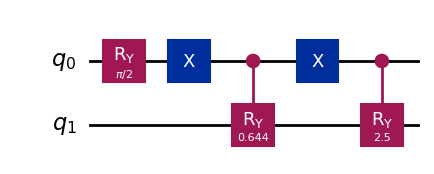

In [22]:
# Preprocessing circuit via package utilities
matrix_circuit = QramBuilder.generate_qram_circuit(example_matrix, optimized_qram=False)
matrix_circuit.draw("mpl")

In [23]:
#Check matrix encoding into quantum state
backend = Aer.get_backend("statevector_simulator")
job = backend.run(transpile(matrix_circuit, backend=backend))
job.result().get_counts()

{np.str_('00'): np.float64(0.45),
 np.str_('01'): np.float64(0.05),
 np.str_('10'): np.float64(0.05),
 np.str_('11'): np.float64(0.45)}

#### Phase Estimation via `PeCircuitBuilder`

In [24]:
# Create and add the phase-estimation block using the package builder
resolution = 5
pe_circuit = PeCircuitBuilder.generate_PE_circuit(example_matrix, resolution, matrix_circuit)

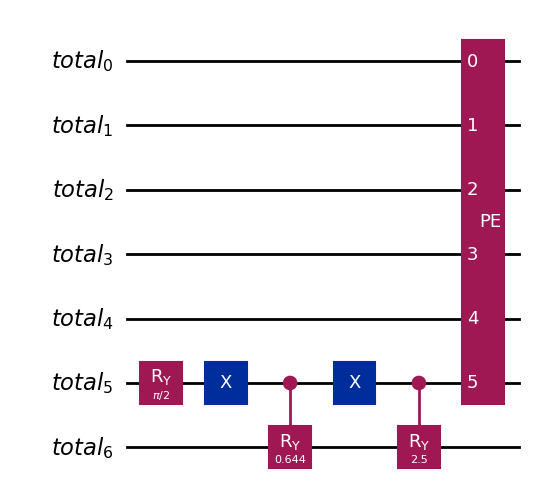

In [25]:
# Optional visual inspection: the circuit should only populate the branches associated with the encoded eigenvalues
pe_circuit.decompose(reps=1).draw("mpl")

#### Quantum State Tomography via `StateVectorTomography`

In [26]:
# Reconstruct the signed statevector through the package tomography utility
n_shots = 50000  # Increase to achieve higher accuracy
backend_simulation = Aer.get_backend("qasm_simulator")
statevector_dictionary = StateVectorTomography.state_vector_tomography(
    quantum_circuit=pe_circuit,
    n_shots=n_shots,
    n_repetitions=1,
    backend=backend_simulation,
 )

In [27]:
# Preview a few reconstructed amplitudes returned by tomography
list(statevector_dictionary.items())[:8]

[('0000000', np.float64(0.01)),
 ('0000001', np.float64(0.03521363372331802)),
 ('0000010', np.float64(0.018973665961010275)),
 ('0000011', np.float64(-0.045607017003965515)),
 ('0000100', np.float64(0.01)),
 ('0000101', np.float64(0.09539392014169457)),
 ('0000110', np.float64(0.054405882034941774)),
 ('0000111', np.float64(0.018439088914585774))]

#### Results via `general_postprocessing`

In [28]:
print("Quantum method results:")
result, mean_threshold = general_postprocessing(
    input_matrix=example_matrix,
    statevector_dictionary=statevector_dictionary,
    resolution=resolution,
    n_shots=n_shots,
    plot_peaks=False,
    eigenvalue_threshold=None,
    abs_tolerance=None,
 )

eigenvalues = []
eigenvectors = []
for eig, eigenvector in result:
    cropped_eigenvector = np.real(eigenvector[:matrix_dimension]).round(3)
    print(f"eigenvalue: {eig * norm_factor} - eigenvector: {cropped_eigenvector}")
    eigenvalues.append(eig * norm_factor)
    eigenvectors.append(list(np.real(eigenvector[:matrix_dimension])))

Quantum method results:
eigenvalue: 1.96875 - eigenvector: [0.713 0.69 ]
eigenvalue: 1.03125 - eigenvector: [ 0.719 -0.676]


You set an absolute tolerance of 2e-05. If some output eigenvalues are not the expected ones, it is recommended to increase the absolute tolerance to cut away the noisy eigenvalues.


In [29]:
reduced_matrix = project_onto_components(original_matrix, eigenvalues, eigenvectors)
reduced_matrix.round(3)

array([[ 1.008,  0.729],
       [ 0.992, -0.645]])

Note: 

1) The signs of the eigenvectors are arbitrary. 
You can flip them without changing the meaning of ther result; only their direction matters.

2) One can improve the accuracy of the algorithm increasing the *resolution* parameter and the number of shots

In [30]:
print("Classically computed values:")
zipped_list = list(zip(np.linalg.eig(original_matrix)[0][::-1], np.rot90(np.linalg.eig(original_matrix)[1])))
cl_eigenvalues = []
cl_eigenvectors = []
for eigenval, eigenvec in sorted(zipped_list, key = lambda x: x[0]):
    print(f'eigenvalue: {eigenval:.0f} - eigenvector: {eigenvec.round(3)}')
    cl_eigenvalues.append(eigenval)
    cl_eigenvectors.append(list(eigenvec))

Classically computed values:
eigenvalue: 1 - eigenvector: [-0.707  0.707]
eigenvalue: 2 - eigenvector: [0.707 0.707]


In [31]:
classically_reduced_matrix = project_onto_components(
    original_matrix, cl_eigenvalues, cl_eigenvectors
 )
classically_reduced_matrix.round(3)

array([[-0.707,  1.   ],
       [ 0.707,  1.   ]])